In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
DATA_DIR = Path(r"C:\Users\brend\OneDrive\School OneDrive")
INPUT_FILES = [DATA_DIR / "2025 CCBL Trackman Data.xlsx"]

OUTPUT_PATH = DATA_DIR / "CatchProbability_v5_results.xlsx"
MODEL_PATH = DATA_DIR / "CatchProbability_v5_model.joblib"

RANDOM_STATE = 42
N_GROUP_FOLDS = 5
N_INNER_FOLDS = 3
LATEST_DATE_FRACTION = 0.20
BLEND_WEIGHT_GRID = np.linspace(0.0, 1.0, 101)

POSITION_DATA_SEASONS = {2025}
POSITIONS = ("1B", "2B", "3B", "SS", "LF", "CF", "RF")
POSITION_RADIUS_BOUNDS = {
    "1B": (40.0, 190.0), "2B": (50.0, 220.0), "3B": (40.0, 190.0),
    "SS": (50.0, 220.0), "LF": (150.0, 450.0), "CF": (175.0, 450.0),
    "RF": (150.0, 450.0),
}

BEARING_ZERO_AXIS = "auto"
MIN_ZONE_TIME, MAX_ZONE_TIME = 0.25, 0.75
MIN_HANG_TIME, MAX_HANG_TIME = 0.50, 12.0
MIN_OPPORTUNITY_TIME, MAX_OPPORTUNITY_TIME = 0.75, 12.75
MIN_BALL_DISTANCE, MAX_BALL_DISTANCE = 15.0, 500.0
MAX_FIELDER_DISTANCE = 300.0
MAX_OPPORTUNITY_REQUIRED_SPEED = 40.0
ACCEPTED_LANDING_CONFIDENCE = {"high", "medium"}

PARK_DIMENSIONS = {
    "Bourne - Doran Park": {"LF": 325.0, "CF": 390.0, "RF": 315.0},
    "Brewster - Stony Brook Field": {"LF": 325.0, "CF": 375.0, "RF": 325.0},
    "Chatham - Veterans Field": {"LF": 325.0, "CF": 385.0, "RF": 314.0},
    "Cotuit - Lowell Park": {"LF": 320.0, "CF": 399.0, "RF": 320.0},
    "Falmouth - Guv Fuller Field": {"LF": 320.0, "CF": 385.0, "RF": 320.0},
    "Harwich - Whitehouse Field": {"LF": 330.0, "CF": 395.0, "RF": 330.0},
    "Hyannis - McKeon Park": {"LF": 320.0, "CF": 394.0, "RF": 324.0},
    "Orleans - Eldredge Park": {"LF": 300.0, "CF": 434.0, "RF": 314.0},
    "Wareham - Spillane Field": {"LF": 325.0, "CF": 400.0, "RF": 330.0},
    "Yarmouth-Dennis - Red Wilson Field": {"LF": 346.0, "CF": 352.0, "RF": 338.0},
}
PARK_ALIASES = {
    "bourne": "Bourne - Doran Park", "doran": "Bourne - Doran Park",
    "brewster": "Brewster - Stony Brook Field", "stonybrook": "Brewster - Stony Brook Field",
    "chatham": "Chatham - Veterans Field", "veterans": "Chatham - Veterans Field",
    "cotuit": "Cotuit - Lowell Park", "lowell": "Cotuit - Lowell Park",
    "falmouth": "Falmouth - Guv Fuller Field", "guvfuller": "Falmouth - Guv Fuller Field",
    "harwich": "Harwich - Whitehouse Field", "whitehouse": "Harwich - Whitehouse Field",
    "hyannis": "Hyannis - McKeon Park", "mckeon": "Hyannis - McKeon Park",
    "orleans": "Orleans - Eldredge Park", "eldredge": "Orleans - Eldredge Park",
    "wareham": "Wareham - Spillane Field", "spillane": "Wareham - Spillane Field",
    "yarmouth": "Yarmouth-Dennis - Red Wilson Field", "redwilson": "Yarmouth-Dennis - Red Wilson Field",
}


In [3]:
def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "", regex=True)
    )


def load_trackman_files(paths: list[Path]) -> pd.DataFrame:
    existing = [Path(p) for p in paths if Path(p).exists()]
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        print("Not found (skipped):")
        for p in missing:
            print("  ", p)
    if not existing:
        raise FileNotFoundError("None of the INPUT_FILES exist. Update DATA_DIR or INPUT_FILES.")

    frames = []
    for path in existing:
        print("Loading:", path)
        frame = pd.read_excel(path, engine="openpyxl")
        frame["SourceFile"] = path.name
        frames.append(frame)
        print(f"  {len(frame):,} rows")
    combined = pd.concat(frames, ignore_index=True, sort=False)
    print(f"Combined rows: {len(combined):,}")
    return combined


def require_columns(frame: pd.DataFrame, columns: list[str]) -> None:
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def identify_position_columns(frame: pd.DataFrame) -> list[dict]:
    positions = []
    missing = []
    for pos in POSITIONS:
        xcol = f"{pos}_PositionAtReleaseX"
        zcol = f"{pos}_PositionAtReleaseZ"
        namecol = f"{pos}_Name"
        missing.extend(c for c in (xcol, zcol, namecol) if c not in frame.columns)
        positions.append({"pos": pos, "xcol": xcol, "zcol": zcol, "namecol": namecol})
    if missing:
        raise ValueError(
            "The seven-fielder model requires every position and name column. "
            f"Missing: {sorted(set(missing))}"
        )
    return positions


def canonical_park(stadium: pd.Series) -> pd.Series:
    normalized = normalize_text(stadium)

    def match(value):
        if pd.isna(value) or not value:
            return "Unknown"
        for alias, park in PARK_ALIASES.items():
            if alias in value:
                return park
        return "Unknown"

    return normalized.map(match).astype("string")


def add_wall_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    require_columns(out, ["Stadium", "Bearing", "Distance"])
    out["Park"] = canonical_park(out["Stadium"])
    out["ParkGeometryKnown"] = out["Park"].ne("Unknown")

    for label in ("LF", "CF", "RF"):
        out[f"Park_{label}_ft"] = out["Park"].map(
            {park: dims[label] for park, dims in PARK_DIMENSIONS.items()}
        )

    bearing = pd.to_numeric(out["Bearing"], errors="coerce")
    fair = bearing.between(-45.0, 45.0)
    clipped = bearing.clip(-45.0, 45.0)
    left_half = out["Park_LF_ft"] + (out["Park_CF_ft"] - out["Park_LF_ft"]) * (
        (clipped + 45.0) / 45.0
    )
    right_half = out["Park_CF_ft"] + (out["Park_RF_ft"] - out["Park_CF_ft"]) * (
        clipped / 45.0
    )
    out["FenceDistanceAtBearing"] = np.where(clipped <= 0, left_half, right_half)
    out.loc[~fair | ~out["ParkGeometryKnown"], "FenceDistanceAtBearing"] = np.nan
    out["DistanceToFence"] = out["FenceDistanceAtBearing"] - out["Distance"]
    out["FenceClearance"] = out["Distance"] - out["FenceDistanceAtBearing"]

    outfielder = out["EstimatedResponsiblePosition"].isin(["LF", "CF", "RF"])
    going_back = out["DepthChange"].gt(0)
    out["NearWallFlag"] = (
        outfielder & going_back & out["DistanceToFence"].between(-10.0, 30.0)
    ).astype(int)
    out["BeyondFenceFlag"] = (
        out["ParkGeometryKnown"] & fair & out["DistanceToFence"].lt(0)
    ).astype(int)
    out["WallDifficultyBand"] = np.select(
        [
            ~out["ParkGeometryKnown"] | ~fair,
            out["BeyondFenceFlag"].eq(1),
            out["NearWallFlag"].eq(1),
        ],
        ["Unknown", "Projected beyond fence", "Near-wall route"],
        default="No immediate wall pressure",
    )
    return out


In [4]:
def infer_bearing_axis(frame: pd.DataFrame, positions: list[dict]) -> str:
    if BEARING_ZERO_AXIS in {"X", "Z"}:
        return BEARING_ZERO_AXIS
    cf = next(p for p in positions if p["pos"] == "CF")
    cf_x = pd.to_numeric(frame[cf["xcol"]], errors="coerce").abs().median()
    cf_z = pd.to_numeric(frame[cf["zcol"]], errors="coerce").abs().median()
    axis = "Z" if cf_x <= cf_z else "X"
    print(f"Bearing convention selected: 0 degrees points along +{axis}")
    return axis


def add_geometry(frame: pd.DataFrame, positions: list[dict]) -> pd.DataFrame:
    out = frame.copy()
    numeric_columns = ["Distance", "Bearing", "HangTime", "ZoneTime"]
    numeric_columns += [p[key] for p in positions for key in ("xcol", "zcol")]
    for col in numeric_columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    radians = np.radians(out["Bearing"])
    axis = infer_bearing_axis(out, positions)
    if axis == "Z":
        out["Ball_X"] = out["Distance"] * np.sin(radians)
        out["Ball_Z"] = out["Distance"] * np.cos(radians)
    else:
        out["Ball_X"] = out["Distance"] * np.cos(radians)
        out["Ball_Z"] = out["Distance"] * np.sin(radians)

    fielder_x = out[[p["xcol"] for p in positions]].to_numpy(dtype=float)
    fielder_z = out[[p["zcol"] for p in positions]].to_numpy(dtype=float)
    ball_x = out["Ball_X"].to_numpy(dtype=float)[:, None]
    ball_z = out["Ball_Z"].to_numpy(dtype=float)[:, None]

    valid_columns = []
    for p in positions:
        radius = np.hypot(out[p["xcol"]], out[p["zcol"]])
        lower, upper = POSITION_RADIUS_BOUNDS[p["pos"]]
        coordinates_present = out[[p["xcol"], p["zcol"]]].notna().all(axis=1)
        name_present = normalize_text(out[p["namecol"]]).fillna("").ne("")
        verified = coordinates_present & name_present & radius.between(lower, upper)
        out[f"{p['pos']}_PositionVerified"] = verified
        valid_columns.append(verified.to_numpy(dtype=bool))

    verified_matrix = np.column_stack(valid_columns)
    out["AllSevenFielderPositionsVerified"] = verified_matrix.all(axis=1)
    candidate_distance = np.hypot(ball_x - fielder_x, ball_z - fielder_z)
    candidate_distance = np.where(verified_matrix, candidate_distance, np.inf)
    valid_any = verified_matrix.any(axis=1) & np.isfinite(candidate_distance).any(axis=1)
    nearest_idx = candidate_distance.argmin(axis=1)
    nearest_idx[~valid_any] = 0

    n = len(out)
    fx, fz = np.full(n, np.nan), np.full(n, np.nan)
    pos_values = np.full(n, None, dtype=object)
    name_values = np.full(n, None, dtype=object)
    for idx, p in enumerate(positions):
        mask = valid_any & (nearest_idx == idx)
        fx[mask] = out.loc[mask, p["xcol"]].to_numpy(dtype=float)
        fz[mask] = out.loc[mask, p["zcol"]].to_numpy(dtype=float)
        pos_values[mask] = p["pos"]
        names = out[p["namecol"]].astype("string").to_numpy(dtype=object)
        name_values[mask] = names[mask]

    out["Fielder_X"], out["Fielder_Z"] = fx, fz
    out["EstimatedResponsiblePosition"] = pos_values
    out["EstimatedResponsibleFielder"] = name_values
    out["ResponsibilityMethod"] = "nearest verified non-catcher fielder at pitch release"

    dx = out["Ball_X"] - out["Fielder_X"]
    dz = out["Ball_Z"] - out["Fielder_Z"]
    start_radius = np.hypot(out["Fielder_X"], out["Fielder_Z"])
    ux, uz = out["Fielder_X"] / start_radius, out["Fielder_Z"] / start_radius
    out["DepthChange"] = dx * ux + dz * uz
    out["LateralChange"] = np.abs(-dx * uz + dz * ux)
    out["FielderDistance"] = np.hypot(dx, dz)
    out["FielderStartDepth"] = start_radius
    out["HangTime_sec"] = out["HangTime"]
    out["PitchFlightTime_sec"] = out["ZoneTime"]
    out["OpportunityTime_sec"] = out["PitchFlightTime_sec"] + out["HangTime_sec"]
    out["RequiredSpeed_HangTime"] = out["FielderDistance"] / out["HangTime_sec"]
    out["RequiredSpeed_Opportunity"] = out["FielderDistance"] / out["OpportunityTime_sec"]
    out["AbsBearing"] = out["Bearing"].abs()
    out["BackFlag"] = (out["DepthChange"] > 0).astype(int)
    return add_wall_features(out)


In [5]:
def add_outcome_and_filters(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = frame.copy()
    require_columns(out, ["TaggedHitType", "PlayResult", "Date", "HitLandingConfidence"])
    hit_type = normalize_text(out["TaggedHitType"])
    is_air_ball = hit_type.str.contains("fly|line|pop", regex=True, na=False)
    result = normalize_text(out["PlayResult"])
    caught_results = {"out", "sacrifice", "sacfly", "sacrificefly"}
    not_caught_results = {"single", "double", "triple", "homerun", "error", "fielderschoice"}
    out["Caught"] = np.select(
        [result.isin(caught_results), result.isin(not_caught_results)],
        [1.0, 0.0], default=np.nan,
    )
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    out["Season"] = out["Date"].dt.year
    landing_confidence = normalize_text(out["HitLandingConfidence"])

    rules = pd.DataFrame(index=out.index)
    rules["AirBall"] = is_air_ball
    rules["KnownOutcome"] = out["Caught"].notna()
    rules["ValidDate"] = out["Date"].notna()
    rules["SeasonHasPositionData"] = out["Season"].isin(POSITION_DATA_SEASONS)
    rules["AcceptableLandingConfidence"] = landing_confidence.isin(ACCEPTED_LANDING_CONFIDENCE)
    rules["KnownParkGeometry"] = out["ParkGeometryKnown"].fillna(False)
    rules["AllSevenFielderPositionsVerified"] = out["AllSevenFielderPositionsVerified"].fillna(False)
    rules["ValidGeometry"] = out[
        ["FielderDistance", "DepthChange", "LateralChange", "FielderStartDepth"]
    ].notna().all(axis=1)
    rules["PlausibleZoneTime"] = out["PitchFlightTime_sec"].between(MIN_ZONE_TIME, MAX_ZONE_TIME)
    rules["PlausibleHangTime"] = out["HangTime_sec"].between(MIN_HANG_TIME, MAX_HANG_TIME)
    rules["PlausibleOpportunityTime"] = out["OpportunityTime_sec"].between(MIN_OPPORTUNITY_TIME, MAX_OPPORTUNITY_TIME)
    rules["PlausibleBallDistance"] = out["Distance"].between(MIN_BALL_DISTANCE, MAX_BALL_DISTANCE)
    rules["PlausibleFielderDistance"] = out["FielderDistance"].between(0, MAX_FIELDER_DISTANCE)
    rules["PlausibleOpportunitySpeed"] = out["RequiredSpeed_Opportunity"].between(0, MAX_OPPORTUNITY_REQUIRED_SPEED)

    summary = pd.DataFrame({
        "Rule": rules.columns,
        "RowsPassing": [int(rules[c].sum()) for c in rules.columns],
        "RowsFailing": [int((~rules[c]).sum()) for c in rules.columns],
    })
    model_frame = out.loc[rules.all(axis=1)].copy()
    group_col = next((c for c in ["GameUID", "GameID", "GameId", "Date"] if c in model_frame.columns), "Date")
    model_frame["ValidationGroup"] = model_frame[group_col].astype("string")
    if "PlayID" in model_frame.columns:
        duplicates = int(model_frame["PlayID"].duplicated().sum())
        if duplicates:
            warnings.warn(f"Removing {duplicates:,} duplicate PlayID rows.")
            model_frame = model_frame.drop_duplicates("PlayID", keep="last")
    model_frame["Caught"] = model_frame["Caught"].astype(int)
    model_frame = model_frame.sort_values(["Date", "ValidationGroup"]).reset_index(drop=True)
    print(f"Eligible plays: {len(model_frame):,}; catch rate: {model_frame['Caught'].mean():.1%}; groups: {model_frame['ValidationGroup'].nunique():,}")
    return model_frame, summary


def tracking_confidence_audit(frame: pd.DataFrame) -> pd.DataFrame:
    hit_type = normalize_text(frame["TaggedHitType"])
    air = hit_type.str.contains("fly|line|pop", regex=True, na=False)
    launch = frame.get("HitLaunchConfidence", pd.Series("Missing", index=frame.index)).astype("string").fillna("Blank")
    landing = frame.get("HitLandingConfidence", pd.Series("Missing", index=frame.index)).astype("string").fillna("Blank")
    return (
        pd.DataFrame({"AirBall": air, "HitLaunchConfidence": launch, "HitLandingConfidence": landing})
        .query("AirBall")
        .groupby(["HitLaunchConfidence", "HitLandingConfidence"], dropna=False)
        .size().rename("AirBallRows").reset_index().sort_values("AirBallRows", ascending=False)
    )


In [6]:
CORE_NUMERIC_FEATURES = [
    "HangTime_sec", "Distance", "FielderDistance", "RequiredSpeed_HangTime",
    "DepthChange", "LateralChange", "FielderStartDepth", "AbsBearing", "BackFlag",
]
CORE_CATEGORICAL_FEATURES = ["EstimatedResponsiblePosition"]
CORE_FEATURES = CORE_NUMERIC_FEATURES + CORE_CATEGORICAL_FEATURES

CONTEXT_NUMERIC_FEATURES = [
    "OpportunityTime_sec", "Distance", "FielderDistance", "RequiredSpeed_Opportunity",
    "DepthChange", "LateralChange", "FielderStartDepth", "AbsBearing", "BackFlag",
    "FenceDistanceAtBearing", "DistanceToFence", "NearWallFlag", "BeyondFenceFlag",
]
CONTEXT_CATEGORICAL_FEATURES = ["EstimatedResponsiblePosition", "Park"]
CONTEXT_FEATURES = CONTEXT_NUMERIC_FEATURES + CONTEXT_CATEGORICAL_FEATURES


def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ], remainder="drop")


def make_nonlinear_model(numeric_features, categorical_features):
    return Pipeline([
        ("prep", make_preprocessor(numeric_features, categorical_features)),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=250, max_leaf_nodes=15,
            min_samples_leaf=30, l2_regularization=1.0,
            early_stopping=True, validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
    ])


def make_core_model():
    return make_nonlinear_model(CORE_NUMERIC_FEATURES, CORE_CATEGORICAL_FEATURES)


def make_context_model():
    return make_nonlinear_model(CONTEXT_NUMERIC_FEATURES, CONTEXT_CATEGORICAL_FEATURES)


def make_logistic_baseline():
    return Pipeline([
        ("prep", make_preprocessor(CONTEXT_NUMERIC_FEATURES, CONTEXT_CATEGORICAL_FEATURES, scale_numeric=True)),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ])


In [7]:
def make_group_splits(X, y, groups, requested_splits=N_GROUP_FOLDS):
    n_groups = pd.Series(groups).nunique()
    n_splits = min(requested_splits, n_groups)
    if n_splits < 2:
        raise ValueError("At least two games/groups are required for validation.")
    try:
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        splits = list(splitter.split(X, y, groups))
        if any(len(np.unique(y[train])) < 2 for train, _ in splits):
            raise ValueError("A training fold contains one class.")
        return splits
    except ValueError:
        warnings.warn("Using GroupKFold because stratified grouped folds were infeasible.")
        return list(GroupKFold(n_splits=n_splits).split(X, y, groups))


def probability_logit(probability):
    clipped = np.clip(np.asarray(probability, dtype=float), 1e-5, 1 - 1e-5)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)


def fit_sigmoid_calibrator(raw_probability, y):
    calibrator = LogisticRegression(C=10.0, max_iter=2000, random_state=RANDOM_STATE)
    calibrator.fit(probability_logit(raw_probability), y)
    return calibrator


def apply_calibrator(calibrator, raw_probability):
    return calibrator.predict_proba(probability_logit(raw_probability))[:, 1]


def grouped_oof_raw_predictions(model_template, X, y, groups, requested_splits=N_GROUP_FOLDS):
    predictions = np.full(len(X), np.nan)
    for train_idx, valid_idx in make_group_splits(X, y, groups, requested_splits):
        model = clone(model_template).fit(X.iloc[train_idx], y[train_idx])
        predictions[valid_idx] = model.predict_proba(X.iloc[valid_idx])[:, 1]
    if np.isnan(predictions).any():
        raise RuntimeError("Some rows did not receive an out-of-fold prediction.")
    return predictions


def nested_grouped_calibrated_oof(model_template, X, y, groups):
    calibrated_oof = np.full(len(X), np.nan)
    raw_oof = np.full(len(X), np.nan)
    outer_splits = make_group_splits(X, y, groups)
    for fold, (train_idx, valid_idx) in enumerate(outer_splits, start=1):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        y_train = y[train_idx]
        groups_train = groups[train_idx]
        inner_raw = grouped_oof_raw_predictions(
            model_template, X_train, y_train, groups_train,
            requested_splits=min(N_INNER_FOLDS, pd.Series(groups_train).nunique()),
        )
        calibrator = fit_sigmoid_calibrator(inner_raw, y_train)
        model = clone(model_template).fit(X.iloc[train_idx], y_train)
        fold_raw = model.predict_proba(X.iloc[valid_idx])[:, 1]
        raw_oof[valid_idx] = fold_raw
        calibrated_oof[valid_idx] = apply_calibrator(calibrator, fold_raw)
        print(f"Completed outer fold {fold}/{len(outer_splits)}")
    if np.isnan(calibrated_oof).any():
        raise RuntimeError("Some rows did not receive calibrated OOF predictions.")
    return calibrated_oof, raw_oof


def fit_deployment_model(model_template, X, y, groups):
    raw_oof = grouped_oof_raw_predictions(model_template, X.reset_index(drop=True), y, groups)
    calibrator = fit_sigmoid_calibrator(raw_oof, y)
    model = clone(model_template).fit(X, y)
    return model, calibrator


In [8]:
def expected_calibration_error(y_true, probability, n_bins=10):
    y_true, probability = np.asarray(y_true), np.asarray(probability)
    edges = np.linspace(0, 1, n_bins + 1)
    bins = np.clip(np.digitize(probability, edges[1:-1]), 0, n_bins - 1)
    return float(sum(
        (bins == b).mean() * abs(y_true[bins == b].mean() - probability[bins == b].mean())
        for b in range(n_bins) if (bins == b).any()
    ))


def metric_row(label, y_true, probability):
    y_true = np.asarray(y_true)
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return {
        "Evaluation": label, "Rows": len(y_true), "CatchRate": float(y_true.mean()),
        "ROC_AUC": float(roc_auc_score(y_true, probability)) if len(np.unique(y_true)) == 2 else np.nan,
        "AveragePrecision": float(average_precision_score(y_true, probability)),
        "LogLoss": float(log_loss(y_true, probability, labels=[0, 1])),
        "BrierScore": float(brier_score_loss(y_true, probability)),
        "ECE_10bins": expected_calibration_error(y_true, probability),
    }


def calibration_table(y_true, probability, label, n_bins=10):
    y_true, probability = np.asarray(y_true), np.asarray(probability)
    edges = np.linspace(0, 1, n_bins + 1)
    bins = np.clip(np.digitize(probability, edges[1:-1]), 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        mask = bins == b
        if mask.any():
            rows.append({"Evaluation": label, "Bin": b + 1, "N": int(mask.sum()),
                         "MeanPredicted": float(probability[mask].mean()),
                         "ObservedCatchRate": float(y_true[mask].mean())})
    return pd.DataFrame(rows)


def chronological_holdout_indices(frame):
    seasons = sorted(frame["Season"].dropna().unique())
    if len(seasons) >= 2:
        test_season = seasons[-1]
        test_mask = frame["Season"].eq(test_season).to_numpy()
        label = f"Future-season holdout ({int(test_season)})"
    else:
        dates = np.array(sorted(frame["Date"].dropna().dt.normalize().unique()))
        cut_position = max(1, int(np.floor(len(dates) * (1 - LATEST_DATE_FRACTION))))
        cut_position = min(cut_position, len(dates) - 1)
        cutoff = dates[cut_position]
        test_mask = frame["Date"].dt.normalize().ge(cutoff).to_numpy()
        label = f"Latest-date holdout (from {pd.Timestamp(cutoff).date()})"
    train_idx, test_idx = np.flatnonzero(~test_mask), np.flatnonzero(test_mask)
    if len(train_idx) < 100 or len(test_idx) < 50:
        raise ValueError("Chronological holdout is too small for reliable evaluation.")
    return train_idx, test_idx, label


def blend_probabilities(core_probability, context_probability, core_weight):
    return core_weight * np.asarray(core_probability) + (1.0 - core_weight) * np.asarray(context_probability)


def select_blend_weight(y_true, core_probability, context_probability):
    rows = []
    for weight in BLEND_WEIGHT_GRID:
        probability = blend_probabilities(core_probability, context_probability, weight)
        rows.append({"CoreWeight": float(weight), "ContextWeight": float(1 - weight),
                     "DevelopmentOOF_LogLoss": float(log_loss(y_true, probability)),
                     "DevelopmentOOF_Brier": float(brier_score_loss(y_true, probability))})
    curve = pd.DataFrame(rows)
    best = curve.sort_values(["DevelopmentOOF_LogLoss", "DevelopmentOOF_Brier", "CoreWeight"]).iloc[0]
    return float(best["CoreWeight"]), curve


def confidence_sensitivity_table(frame):
    landing = normalize_text(frame["HitLandingConfidence"])
    launch = normalize_text(frame["HitLaunchConfidence"]) if "HitLaunchConfidence" in frame else pd.Series("missing", index=frame.index)
    subsets = {
        "Primary sample — landing High/Medium": pd.Series(True, index=frame.index),
        "Landing confidence High only": landing.eq("high"),
        "Launch and landing High only": launch.eq("high") & landing.eq("high"),
    }
    rows = []
    for label, mask in subsets.items():
        if mask.sum() < 25:
            continue
        row = metric_row(label, frame.loc[mask, "Caught"], frame.loc[mask, "Evaluation_CatchProbability"])
        row["ConfidenceSubset"] = label
        rows.append(row)
    return pd.DataFrame(rows)


In [9]:
raw_df = load_trackman_files(INPUT_FILES)
require_columns(raw_df, [
    "Distance", "Bearing", "HangTime", "ZoneTime", "Stadium",
    "TaggedHitType", "PlayResult", "Date", "HitLandingConfidence",
])
position_columns = identify_position_columns(raw_df)
geometry_df = add_geometry(raw_df, position_columns)
confidence_audit = tracking_confidence_audit(geometry_df)
df_model, filter_summary = add_outcome_and_filters(geometry_df)

if df_model.empty or df_model["Caught"].nunique() < 2:
    raise ValueError("The eligible data must contain both caught and not-caught plays.")

X_core = df_model[CORE_FEATURES].copy()
X_context = df_model[CONTEXT_FEATURES].copy()
y = df_model["Caught"].to_numpy(dtype=int)
groups = df_model["ValidationGroup"].to_numpy()
development_idx, holdout_idx, holdout_label = chronological_holdout_indices(df_model)

print(holdout_label)
print(f"Development rows: {len(development_idx):,}; untouched holdout rows: {len(holdout_idx):,}")
display(filter_summary)
display(confidence_audit)


Loading: C:\Users\brend\OneDrive\School OneDrive\2025 CCBL Trackman Data.xlsx
  114,410 rows
Combined rows: 114,410
Bearing convention selected: 0 degrees points along +X
Eligible plays: 1,945; catch rate: 55.5%; groups: 98
Latest-date holdout (from 2025-08-05)
Development rows: 1,688; untouched holdout rows: 257


,Rule,RowsPassing,RowsFailing
0,AirBall,10060,104350
1,KnownOutcome,18587,95823
2,ValidDate,113905,505
3,SeasonHasPositionData,55405,59005
4,AcceptableLandingConfidence,15228,99182
5,KnownParkGeometry,114396,14
6,AllSevenFielderPositionsVerified,26147,88263
7,ValidGeometry,6652,107758
8,PlausibleZoneTime,112936,1474
9,PlausibleHangTime,16042,98368


,HitLaunchConfidence,HitLandingConfidence,AirBallRows
5,High,High,5067
7,High,Medium,1794
0,Blank,Blank,741
6,High,Low,584
16,Medium,Low,458
4,High,Blank,321
17,Medium,Medium,237
18,Medium,Undefined,189
14,Medium,Blank,152
15,Medium,High,138


In [10]:
core_template = make_core_model()
context_template = make_context_model()
logistic_template = make_logistic_baseline()

X_core_dev = X_core.iloc[development_idx].reset_index(drop=True)
X_context_dev = X_context.iloc[development_idx].reset_index(drop=True)
y_dev = y[development_idx]
groups_dev = groups[development_idx]

print("Core branch OOF evaluation")
core_dev_oof, core_dev_raw = nested_grouped_calibrated_oof(core_template, X_core_dev, y_dev, groups_dev)
print("Context branch OOF evaluation")
context_dev_oof, context_dev_raw = nested_grouped_calibrated_oof(context_template, X_context_dev, y_dev, groups_dev)

core_weight, blend_curve = select_blend_weight(y_dev, core_dev_oof, context_dev_oof)
context_weight = 1.0 - core_weight
ensemble_dev_oof = blend_probabilities(core_dev_oof, context_dev_oof, core_weight)
logistic_dev_oof = grouped_oof_raw_predictions(logistic_template, X_context_dev, y_dev, groups_dev)

development_metrics = pd.DataFrame([
    metric_row("Development grouped OOF — core branch", y_dev, core_dev_oof),
    metric_row("Development grouped OOF — context branch", y_dev, context_dev_oof),
    metric_row("Development grouped OOF — blended ensemble", y_dev, ensemble_dev_oof),
    metric_row("Development grouped OOF — logistic baseline", y_dev, logistic_dev_oof),
])

print(f"Frozen ensemble weights: core={core_weight:.2f}, context={context_weight:.2f}")
display(development_metrics.round(4))


Core branch OOF evaluation
Completed outer fold 1/5
Completed outer fold 2/5
Completed outer fold 3/5
Completed outer fold 4/5
Completed outer fold 5/5
Context branch OOF evaluation
Completed outer fold 1/5
Completed outer fold 2/5
Completed outer fold 3/5
Completed outer fold 4/5
Completed outer fold 5/5
Frozen ensemble weights: core=0.31, context=0.69


,Evaluation,Rows,CatchRate,ROC_AUC,AveragePrecision,LogLoss,BrierScore,ECE_10bins
0,Development grouped OOF — core branch,1688,0.5586,0.9420,0.9514,0.3046,0.0927,0.0124
1,Development grouped OOF — context branch,1688,0.5586,0.9452,0.9537,0.2961,0.0891,0.0182
2,Development grouped OOF — blended ensemble,1688,0.5586,0.9463,0.9548,0.2936,0.0884,0.0136
3,Development grouped OOF — logistic baseline,1688,0.5586,0.9196,0.9358,0.3631,0.1101,0.0255


In [11]:
core_dev_model, core_dev_calibrator = fit_deployment_model(core_template, X_core_dev, y_dev, groups_dev)
context_dev_model, context_dev_calibrator = fit_deployment_model(context_template, X_context_dev, y_dev, groups_dev)

core_holdout = apply_calibrator(core_dev_calibrator, core_dev_model.predict_proba(X_core.iloc[holdout_idx])[:, 1])
context_holdout = apply_calibrator(context_dev_calibrator, context_dev_model.predict_proba(X_context.iloc[holdout_idx])[:, 1])
ensemble_holdout = blend_probabilities(core_holdout, context_holdout, core_weight)

logistic_holdout_model = clone(logistic_template).fit(X_context_dev, y_dev)
logistic_holdout = logistic_holdout_model.predict_proba(X_context.iloc[holdout_idx])[:, 1]
y_holdout = y[holdout_idx]

holdout_metrics = pd.DataFrame([
    metric_row(f"{holdout_label} — core branch", y_holdout, core_holdout),
    metric_row(f"{holdout_label} — context branch", y_holdout, context_holdout),
    metric_row(f"{holdout_label} — blended ensemble", y_holdout, ensemble_holdout),
    metric_row(f"{holdout_label} — logistic baseline", y_holdout, logistic_holdout),
    metric_row(f"{holdout_label} — constant baseline", y_holdout, np.full(len(y_holdout), y_dev.mean())),
])

evaluation_core = np.full(len(df_model), np.nan)
evaluation_context = np.full(len(df_model), np.nan)
evaluation_ensemble = np.full(len(df_model), np.nan)
evaluation_core[development_idx], evaluation_core[holdout_idx] = core_dev_oof, core_holdout
evaluation_context[development_idx], evaluation_context[holdout_idx] = context_dev_oof, context_holdout
evaluation_ensemble[development_idx], evaluation_ensemble[holdout_idx] = ensemble_dev_oof, ensemble_holdout

df_model["Evaluation_CoreProbability"] = evaluation_core
df_model["Evaluation_ContextProbability"] = evaluation_context
df_model["Evaluation_CatchProbability"] = evaluation_ensemble
df_model["EvaluationSample"] = "Development grouped OOF"
df_model.loc[holdout_idx, "EvaluationSample"] = holdout_label
df_model["PlayDifficultyResidual"] = df_model["Caught"] - df_model["Evaluation_CatchProbability"]

combined_metric = pd.DataFrame([
    metric_row("All leakage-safe evaluation plays — ensemble", y, evaluation_ensemble)
])
metrics = pd.concat([development_metrics, holdout_metrics, combined_metric], ignore_index=True)
confidence_sensitivity = confidence_sensitivity_table(df_model)

display(holdout_metrics.round(4))
display(confidence_sensitivity.round(4))


,Evaluation,Rows,CatchRate,ROC_AUC,AveragePrecision,LogLoss,BrierScore,ECE_10bins
0,Latest-date holdout (from 2025-08-05) — core b...,257,0.5331,0.9563,0.9418,0.2596,0.0744,0.0503
1,Latest-date holdout (from 2025-08-05) — contex...,257,0.5331,0.9581,0.9538,0.2546,0.0754,0.0422
2,Latest-date holdout (from 2025-08-05) — blende...,257,0.5331,0.9582,0.9509,0.2534,0.0739,0.0358
3,Latest-date holdout (from 2025-08-05) — logist...,257,0.5331,0.9423,0.9514,0.3173,0.0966,0.0407
4,Latest-date holdout (from 2025-08-05) — consta...,257,0.5331,0.5000,0.5331,0.6923,0.2496,0.0256


,Evaluation,Rows,CatchRate,ROC_AUC,AveragePrecision,LogLoss,BrierScore,ECE_10bins,ConfidenceSubset
0,Primary sample — landing High/Medium,1945,0.5553,0.9481,0.9542,0.2883,0.0865,0.0146,Primary sample — landing High/Medium
1,Landing confidence High only,1378,0.4717,0.9440,0.9341,0.3020,0.0900,0.0242,Landing confidence High only
2,Launch and landing High only,1339,0.4765,0.9444,0.9380,0.3015,0.0902,0.0259,Launch and landing High only


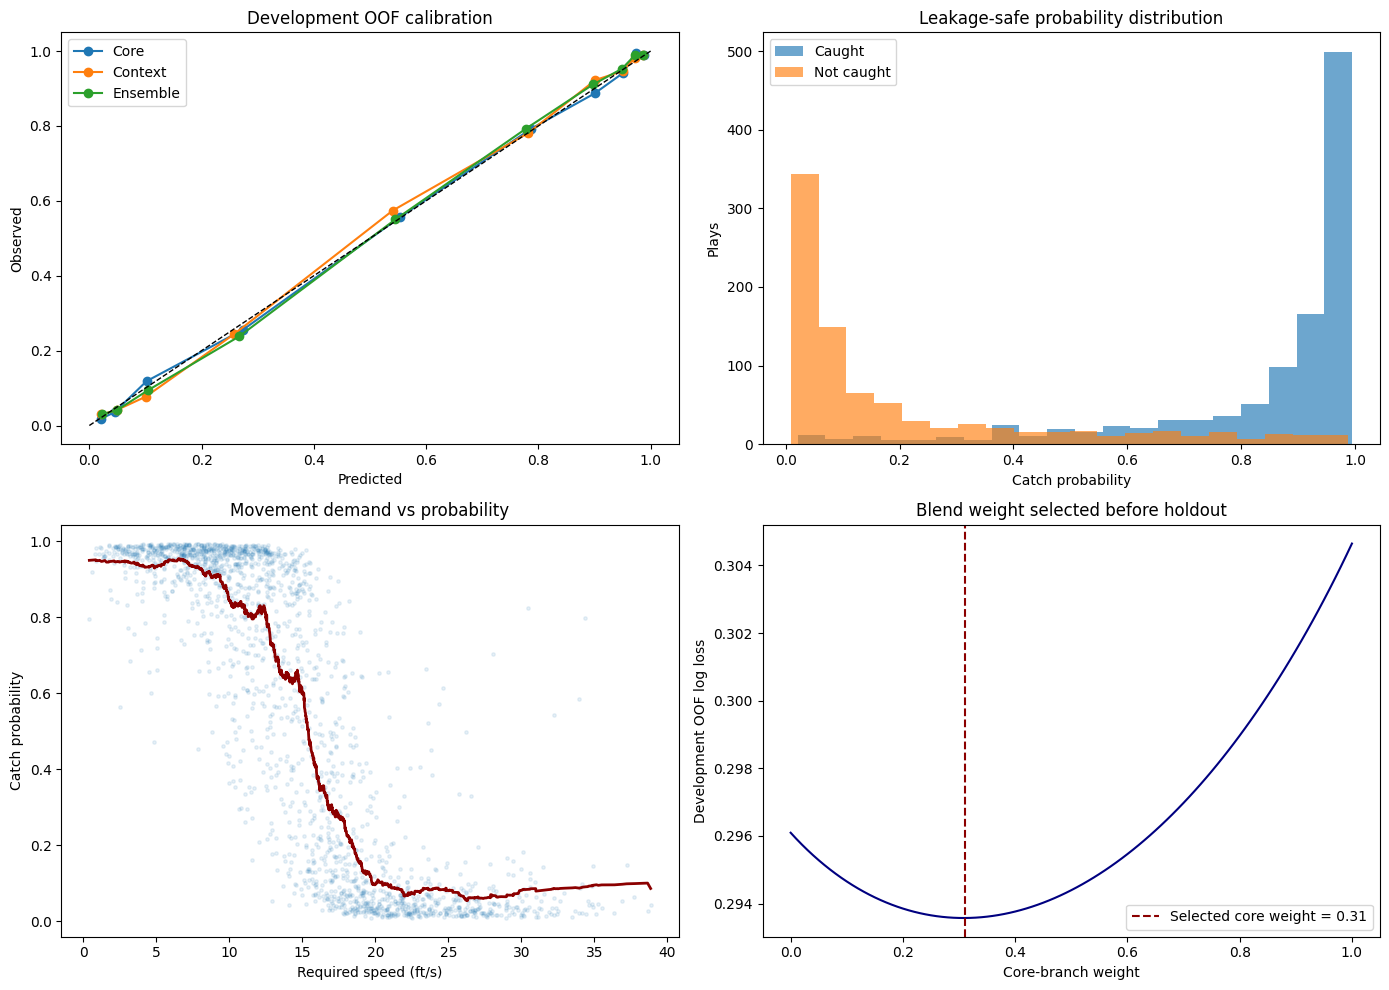

,Branch,Feature,AUC_ImportanceMean,AUC_ImportanceSD
13,Context,RequiredSpeed_Opportunity,0.2135,0.0236
10,Context,OpportunityTime_sec,0.0791,0.0121
20,Context,DistanceToFence,0.0140,0.0037
15,Context,LateralChange,0.0123,0.0045
11,Context,Distance,0.0020,0.0024
14,Context,DepthChange,0.0017,0.0029
17,Context,AbsBearing,0.0009,0.0023
24,Context,Park,0.0006,0.0009
22,Context,BeyondFenceFlag,0.0000,0.0000
18,Context,BackFlag,0.0000,0.0000


In [12]:
calibration_results = pd.concat([
    calibration_table(y_dev, ensemble_dev_oof, "Development grouped OOF — ensemble"),
    calibration_table(y_holdout, ensemble_holdout, f"{holdout_label} — ensemble"),
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for probability, label in [(core_dev_oof, "Core"), (context_dev_oof, "Context"), (ensemble_dev_oof, "Ensemble")]:
    observed, predicted = calibration_curve(y_dev, probability, n_bins=10, strategy="quantile")
    axes[0, 0].plot(predicted, observed, marker="o", label=label)
axes[0, 0].plot([0, 1], [0, 1], "--", color="black", linewidth=1)
axes[0, 0].set(title="Development OOF calibration", xlabel="Predicted", ylabel="Observed")
axes[0, 0].legend()

axes[0, 1].hist(evaluation_ensemble[y == 1], bins=20, alpha=0.65, label="Caught")
axes[0, 1].hist(evaluation_ensemble[y == 0], bins=20, alpha=0.65, label="Not caught")
axes[0, 1].set(title="Leakage-safe probability distribution", xlabel="Catch probability", ylabel="Plays")
axes[0, 1].legend()

plot_frame = pd.DataFrame({"speed": df_model["RequiredSpeed_Opportunity"], "prob": evaluation_ensemble}).sort_values("speed")
plot_frame["rolling_prob"] = plot_frame["prob"].rolling(100, center=True, min_periods=30).mean()
axes[1, 0].scatter(plot_frame["speed"], plot_frame["prob"], s=6, alpha=0.10)
axes[1, 0].plot(plot_frame["speed"], plot_frame["rolling_prob"], color="darkred", linewidth=2)
axes[1, 0].set(title="Movement demand vs probability", xlabel="Required speed (ft/s)", ylabel="Catch probability")

axes[1, 1].plot(blend_curve["CoreWeight"], blend_curve["DevelopmentOOF_LogLoss"], color="navy")
axes[1, 1].axvline(core_weight, linestyle="--", color="darkred", label=f"Selected core weight = {core_weight:.2f}")
axes[1, 1].set(title="Blend weight selected before holdout", xlabel="Core-branch weight", ylabel="Development OOF log loss")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

importance_rows = []
for branch, model, X_test, features in [
    ("Core", core_dev_model, X_core.iloc[holdout_idx], CORE_FEATURES),
    ("Context", context_dev_model, X_context.iloc[holdout_idx], CONTEXT_FEATURES),
]:
    result = permutation_importance(model, X_test, y_holdout, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
    importance_rows.extend({"Branch": branch, "Feature": feature,
                            "AUC_ImportanceMean": mean, "AUC_ImportanceSD": sd}
                           for feature, mean, sd in zip(features, result.importances_mean, result.importances_std))
feature_importance = pd.DataFrame(importance_rows).sort_values(["Branch", "AUC_ImportanceMean"], ascending=[True, False])
display(feature_importance.round(4))


In [13]:
final_core_model, final_core_calibrator = fit_deployment_model(core_template, X_core, y, groups)
final_context_model, final_context_calibrator = fit_deployment_model(context_template, X_context, y, groups)

final_core_probability = apply_calibrator(final_core_calibrator, final_core_model.predict_proba(X_core)[:, 1])
final_context_probability = apply_calibrator(final_context_calibrator, final_context_model.predict_proba(X_context)[:, 1])
df_model["FinalModel_CoreFittedProbability"] = final_core_probability
df_model["FinalModel_ContextFittedProbability"] = final_context_probability
df_model["FinalModel_FittedProbability"] = blend_probabilities(final_core_probability, final_context_probability, core_weight)

preferred_export_columns = [
    "Date", "Season", "SourceFile", "GameUID", "GameID", "PlayID", "Batter", "Pitcher",
    "TaggedHitType", "PlayResult", "Stadium", "Park", "HitLaunchConfidence", "HitLandingConfidence",
    "Distance", "Bearing", "HangTime_sec", "PitchFlightTime_sec", "OpportunityTime_sec",
    "FielderDistance", "DepthChange", "LateralChange", "RequiredSpeed_HangTime", "RequiredSpeed_Opportunity",
    "FenceDistanceAtBearing", "DistanceToFence", "FenceClearance", "NearWallFlag", "BeyondFenceFlag",
    "WallDifficultyBand", "EstimatedResponsiblePosition", "EstimatedResponsibleFielder", "ResponsibilityMethod",
    "Caught", "EvaluationSample", "Evaluation_CoreProbability", "Evaluation_ContextProbability",
    "Evaluation_CatchProbability", "PlayDifficultyResidual", "FinalModel_CoreFittedProbability",
    "FinalModel_ContextFittedProbability", "FinalModel_FittedProbability", "ValidationGroup",
]
play_predictions = df_model[[c for c in preferred_export_columns if c in df_model.columns]].copy()
park_dimensions_table = pd.DataFrame([
    {"Park": park, "LF_ft": dims["LF"], "CF_ft": dims["CF"], "RF_ft": dims["RF"]}
    for park, dims in PARK_DIMENSIONS.items()
])
model_summary = pd.DataFrame([
    {"Item": "Final method", "Value": "Calibrated two-branch probability ensemble"},
    {"Item": "Core weight", "Value": core_weight},
    {"Item": "Context weight", "Value": context_weight},
    {"Item": "Weight selection", "Value": "Minimum development grouped-OOF log loss; frozen before holdout"},
    {"Item": "Historical probability column", "Value": "Evaluation_CatchProbability"},
    {"Item": "Deployment probability column", "Value": "FinalModel_FittedProbability"},
])

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    play_predictions.to_excel(writer, sheet_name="Play Predictions", index=False)
    model_summary.to_excel(writer, sheet_name="Model Summary", index=False)
    metrics.to_excel(writer, sheet_name="Model Metrics", index=False)
    calibration_results.to_excel(writer, sheet_name="Calibration", index=False)
    feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)
    blend_curve.to_excel(writer, sheet_name="Blend Selection", index=False)
    confidence_sensitivity.to_excel(writer, sheet_name="Confidence Sensitivity", index=False)
    confidence_audit.to_excel(writer, sheet_name="Confidence Audit", index=False)
    filter_summary.to_excel(writer, sheet_name="Filter Audit", index=False)
    park_dimensions_table.to_excel(writer, sheet_name="Park Dimensions", index=False)

model_bundle = {
    "core_model": final_core_model, "core_calibrator": final_core_calibrator,
    "context_model": final_context_model, "context_calibrator": final_context_calibrator,
    "core_weight": core_weight, "context_weight": context_weight,
    "core_features": CORE_FEATURES, "context_features": CONTEXT_FEATURES,
    "eligible_position_seasons": sorted(POSITION_DATA_SEASONS),
    "accepted_landing_confidence": sorted(ACCEPTED_LANDING_CONFIDENCE),
    "opportunity_time_definition": "ZoneTime + HangTime",
    "park_dimensions": PARK_DIMENSIONS, "wall_height_included": False,
    "responsibility_method": "nearest verified non-catcher fielder at pitch release",
    "training_date_min": str(df_model["Date"].min().date()),
    "training_date_max": str(df_model["Date"].max().date()),
}
joblib.dump(model_bundle, MODEL_PATH)
print("Saved results:", OUTPUT_PATH)
print("Saved model:", MODEL_PATH)
display(model_summary)
display(play_predictions.head())


Saved results: C:\Users\brend\OneDrive\School OneDrive\CatchProbability_v5_results.xlsx
Saved model: C:\Users\brend\OneDrive\School OneDrive\CatchProbability_v5_model.joblib


,Item,Value
0,Final method,Calibrated two-branch probability ensemble
1,Core weight,0.31
2,Context weight,0.69
3,Weight selection,Minimum development grouped-OOF log loss; froz...
4,Historical probability column,Evaluation_CatchProbability
5,Deployment probability column,FinalModel_FittedProbability


,Date,Season,SourceFile,GameUID,GameID,PlayID,Batter,Pitcher,TaggedHitType,PlayResult,Stadium,Park,HitLaunchConfidence,HitLandingConfidence,Distance,Bearing,HangTime_sec,PitchFlightTime_sec,OpportunityTime_sec,FielderDistance,DepthChange,LateralChange,RequiredSpeed_HangTime,RequiredSpeed_Opportunity,FenceDistanceAtBearing,DistanceToFence,FenceClearance,NearWallFlag,BeyondFenceFlag,WallDifficultyBand,EstimatedResponsiblePosition,EstimatedResponsibleFielder,ResponsibilityMethod,Caught,EvaluationSample,Evaluation_CoreProbability,Evaluation_ContextProbability,Evaluation_CatchProbability,PlayDifficultyResidual,FinalModel_CoreFittedProbability,FinalModel_ContextFittedProbability,FinalModel_FittedProbability,ValidationGroup
0,2025-07-06,2025.0,2025 CCBL Trackman Data.xlsx,245a8e51-0ab8-4eb5-9701-492fe3ff58a5,20250706-CCBLOrleans-1,ce8a2238-c182-4332-a7d0-e5f9d1943814,"Potestio, Anthony","Colucci, Joe",FlyBall,Double,CCBLOrleans,Orleans - Eldredge Park,High,Medium,301.01460,-19.215577,3.539309,0.408916,3.948225,60.933187,32.174301,51.746185,17.216125,15.433058,376.780282,75.765682,-75.765682,0,0,No immediate wall pressure,LF,"Kelly, Gavin",nearest verified non-catcher fielder at pitch ...,0,Development grouped OOF,0.911801,0.774048,0.816751,-0.816751,0.680451,0.453546,0.523887,245a8e51-0ab8-4eb5-9701-492fe3ff58a5
1,2025-07-06,2025.0,2025 CCBL Trackman Data.xlsx,245a8e51-0ab8-4eb5-9701-492fe3ff58a5,20250706-CCBLOrleans-1,79cabeda-884b-47ed-9e24-e49161d832e7,"Lavey, Robbie","Colucci, Joe",LineDrive,Single,CCBLOrleans,Orleans - Eldredge Park,High,High,255.14547,-6.364955,2.489130,0.414038,2.903168,46.349563,-44.313994,13.584987,18.620788,15.965167,415.046578,159.901108,-159.901108,0,0,No immediate wall pressure,CF,"Groves, Nick",nearest verified non-catcher fielder at pitch ...,0,Development grouped OOF,0.118672,0.076037,0.089254,-0.089254,0.044323,0.026035,0.031704,245a8e51-0ab8-4eb5-9701-492fe3ff58a5
2,2025-07-06,2025.0,2025 CCBL Trackman Data.xlsx,245a8e51-0ab8-4eb5-9701-492fe3ff58a5,20250706-CCBLOrleans-1,a644887b-ffcf-4d4d-ac55-3c12885e3aa4,"Garza, Alejandro","Colucci, Joe",LineDrive,Double,CCBLOrleans,Orleans - Eldredge Park,High,Medium,246.34294,42.293586,3.435768,0.412056,3.847824,93.857969,-45.633338,82.017783,27.317901,24.392480,321.217104,74.874164,-74.874164,0,0,No immediate wall pressure,RF,"Aloy, Kuhio",nearest verified non-catcher fielder at pitch ...,0,Development grouped OOF,0.097834,0.098961,0.098612,-0.098612,0.040044,0.023064,0.028327,245a8e51-0ab8-4eb5-9701-492fe3ff58a5
3,2025-07-06,2025.0,2025 CCBL Trackman Data.xlsx,245a8e51-0ab8-4eb5-9701-492fe3ff58a5,20250706-CCBLOrleans-1,65c9d581-5033-4e20-8c2a-eabdaa54b8d4,"Bryce, Dawson","Colucci, Joe",LineDrive,Out,CCBLOrleans,Orleans - Eldredge Park,High,Medium,135.88548,-36.952134,1.261701,0.480080,1.741781,28.970073,28.906735,1.914630,22.961124,16.632443,323.964757,188.079277,-188.079277,0,0,No immediate wall pressure,3B,"Holcomb, Braden",nearest verified non-catcher fielder at pitch ...,1,Development grouped OOF,0.808894,0.703259,0.736006,0.263994,0.851660,0.859050,0.856759,245a8e51-0ab8-4eb5-9701-492fe3ff58a5
4,2025-07-06,2025.0,2025 CCBL Trackman Data.xlsx,245a8e51-0ab8-4eb5-9701-492fe3ff58a5,20250706-CCBLOrleans-1,33f33a15-cfc9-4aab-aa7a-c9ea566141ef,"Hughes, Logan","Koch, Mason",LineDrive,Single,CCBLOrleans,Orleans - Eldredge Park,High,High,208.24265,22.755506,2.010620,0.419842,2.430462,55.128705,54.491153,8.359924,27.418759,22.682397,373.318651,165.076001,-165.076001,0,0,No immediate wall pressure,2B,"Nixon, Luke",nearest verified non-catcher fielder at pitch ...,0,Development grouped OOF,0.021343,0.024139,0.023272,-0.023272,0.012229,0.009781,0.010540,245a8e51-0ab8-4eb5-9701-492fe3ff58a5


In [14]:
def predict_prepared_frame(prepared_frame: pd.DataFrame, bundle: dict) -> np.ndarray:
    core_raw = bundle["core_model"].predict_proba(prepared_frame[bundle["core_features"]])[:, 1]
    context_raw = bundle["context_model"].predict_proba(prepared_frame[bundle["context_features"]])[:, 1]
    core_probability = apply_calibrator(bundle["core_calibrator"], core_raw)
    context_probability = apply_calibrator(bundle["context_calibrator"], context_raw)
    return blend_probabilities(core_probability, context_probability, bundle["core_weight"])


def lookup_play(frame, batter="", fielder="", caught=None):
    mask = pd.Series(True, index=frame.index)
    if batter:
        mask &= frame.get("Batter", pd.Series("", index=frame.index)).astype("string").str.contains(batter, case=False, na=False, regex=False)
    if fielder:
        mask &= frame["EstimatedResponsibleFielder"].astype("string").str.contains(fielder, case=False, na=False, regex=False)
    if caught is not None:
        mask &= frame["Caught"].eq(int(caught))
    columns = [c for c in [
        "Date", "PlayID", "Batter", "EstimatedResponsibleFielder", "Caught",
        "FielderDistance", "OpportunityTime_sec", "RequiredSpeed_Opportunity", "Park",
        "DistanceToFence", "WallDifficultyBand", "HitLandingConfidence",
        "Evaluation_CoreProbability", "Evaluation_ContextProbability",
        "Evaluation_CatchProbability", "PlayDifficultyResidual",
    ] if c in frame.columns]
    return frame.loc[mask, columns].sort_values("Date")
